<a href="https://colab.research.google.com/github/HafizaNoorUlSaba/langgraph/blob/main/Persistant_Memory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Install Packages***

In [1]:
!pip install -q -U langgraph
!pip install -q -U langchain
!pip install -q -U langchain-google-genai
!pip install -q -U langgraph-checkpoint
!pip install -q -U langgraph-checkpoint-sqlite
!pip install -q -U grandalf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.8/247.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.6/139.6 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.8/72.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.4/163.4 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.7 MB/s eta 0:00:00


***Import Libraries***

In [2]:
import os
import sqlite3

from typing import TypedDict
from typing import Annotated

from langgraph.graph import StateGraph
from langgraph.graph import START
from langgraph.graph import END
from langgraph.graph.message import add_messages

from langgraph.checkpoint.sqlite import SqliteSaver

from langchain_core.messages import (
    HumanMessage,
    AIMessage,
    AnyMessage
)

from langchain_google_genai import ChatGoogleGenerativeAI

from IPython.display import Image, display

In [3]:
import os
from google.colab import userdata
Google_Api_Key_from_secrets = userdata.get('Google_Api_Key')

if Google_Api_Key_from_secrets:
    os.environ['Google_Api_Key'] = Google_Api_Key_from_secrets
    print("Google_Api_Key loaded from Colab secrets.")
else:
    print("Warning: Google_Api_Key secret not found in Colab secrets. Please ensure it's set correctly.")

Google_Api_Key loaded from Colab secrets.


In [4]:
llm = ChatGoogleGenerativeAI(
    google_api_key=os.environ.get('Google_Api_Key'),
    model="gemini-2.5-flash",
    temperature=0
)
model=llm

***Create State***

In [5]:
class AgentState(TypedDict):

    messages: Annotated[
        list[AnyMessage],
        add_messages
    ]

***Chatbot Node***

In [6]:
def chatbot(state: AgentState):

    response = llm.invoke(
        state["messages"]
    )

    return {

        "messages":[

            AIMessage(
                content=response.content
            )

        ]

    }

***Create Graph***

In [7]:
builder = StateGraph(AgentState)

builder.add_node(
    "Chatbot",
    chatbot
)

builder.add_edge(
    START,
    "Chatbot"
)

builder.add_edge(
    "Chatbot",
    END
)

***Create SQLite Database***

In [8]:
conn = sqlite3.connect(
    "memory.db",
    check_same_thread=False
)

In [9]:
memory = SqliteSaver(conn)

***Compile Graph***

In [10]:
app = builder.compile()

In [11]:
app = builder.compile(
    checkpointer=memory
)

***Visualize***

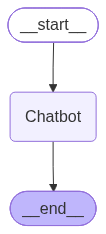

In [12]:
display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

In [13]:
config = {

    "configurable":{

        "thread_id":"customer_001"

    }

}

In [14]:
response = app.invoke(

    {

        "messages":[

            HumanMessage(
                content="My name is Noor."
            )

        ]

    },

    config=config

)

print(
    response["messages"][-1].content
)

Hi Noor! It's nice to meet you.


In [15]:
response = app.invoke(

    {

        "messages":[

            HumanMessage(
                content="What is my name?"
            )

        ]

    },

    config=config

)

print(
    response["messages"][-1].content
)

Your name is Noor.


***Different User***

In [16]:
config2 = {

    "configurable":{

        "thread_id":"customer_002"

    }

}

In [17]:
response = app.invoke(

    {

        "messages":[

            HumanMessage(
                content="What is my name?"
            )

        ]

    },

    config=config2

)

print(
    response["messages"][-1].content
)

As an AI, I don't have access to personal information about you, including your name. I don't retain details from our conversations or know who you are personally.

If you'd like me to refer to you by a specific name during this chat, please feel free to tell me!


In [18]:
response = app.invoke(

    {

        "messages":[

            HumanMessage(
                content="Do you remember me?"
            )

        ]

    },

    config=config

)

print(
    response["messages"][-1].content
)

Yes, I do! You told me your name is Noor.


In [19]:
users = [

    "customer_001",

    "customer_002",

    "customer_003",

    "customer_004"

]

In [20]:
def chat(user_id, question):

    config = {

        "configurable":{

            "thread_id":user_id

        }

    }

    response = app.invoke(

        {

            "messages":[

                HumanMessage(
                    content=question
                )

            ]

        },

        config=config

    )

    print(
        response["messages"][-1].content
    )